# COS711 Assignment 1: MLP on Protein Tertiary Structure

Goal: predict the RMSD (in Å) of a candidate protein structure from its physicochemical features. Then study how MLP design choices affect training, and whether learning-rate warmup makes a network more robust to pruning.

The code lives in short modules in `src/`. This notebook runs the experiments and shows the results.

| Section | Contents |
|---|---|
| 1 | Data preparation |
| 2 | MLP, training loop and baseline |
| 3 | Core investigation: optimisers, architecture, activation functions |
| 4 | Research investigation: warmup and pruning |
| 5 | Figures for the report |

Run with Restart & Run All. Saved results in `results/` are reused, so a full run takes about 3 minutes. Set `RERUN = True` in section 3 to retrain everything (about 15 minutes).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import (FEATURES, INPUT_FEATURES, TARGET, RMSD_BIN_EDGES, RMSD_BIN_LABELS,
                      load_raw, clean, rmsd_bin, split_train_test, stratified_kfold)
from src.preprocessing import Preprocessor, LOG_FEATURES
from src.evaluation import regression_metrics, per_bin_metrics
from src import plotting
from src.plotting import BLUE, ORANGE, TEXT_PRIMARY, TEXT_SECONDARY

plotting.apply_style()
pd.set_option("display.precision", 3)

## 1. Data preparation

After the test set is split off (1.2), every decision uses the training set only.

### 1.1 First look

In [2]:
df_raw = load_raw()
print(f"raw shape: {df_raw.shape}")
print(f"missing values: {df_raw.isna().sum().sum()}")
print(f"exact duplicate rows: {df_raw.duplicated().sum()}")
print(f"rows sharing identical features but different RMSD: "
      f"{df_raw.drop_duplicates().duplicated(FEATURES, keep=False).sum()}")

df = clean(df_raw)
print(f"after removing duplicates: {df.shape}")

raw shape: (45730, 10)
missing values: 0
exact duplicate rows: 1711
rows sharing identical features but different RMSD: 83
after removing duplicates: (44019, 10)


In [3]:
summary = df.describe(percentiles=[0.01, 0.5, 0.99]).T
summary["skew"] = df.skew()
summary

,count,mean,std,min,1%,50%,99%,max,skew
F1,44019.0,9.875e+03,4054.023,2392.050,3946.457,8.903e+03,2.254e+04,4.003e+04,1.095
F2,44019.0,3.019e+03,1465.353,403.500,880.554,2.671e+03,7.477e+03,1.531e+04,1.193
F3,44019.0,3.025e-01,0.063,0.092,0.167,3.002e-01,4.605e-01,5.777e-01,0.240
F4,44019.0,1.035e+02,55.298,10.310,32.623,8.778e+01,2.883e+02,3.693e+02,1.222
F5,44019.0,1.369e+06,563505.024,319490.217,543853.811,1.238e+06,3.110e+06,5.472e+06,1.061
F6,44019.0,1.457e+02,69.870,31.970,48.752,1.262e+02,3.601e+02,5.984e+02,1.119
F7,44019.0,3.992e+03,2006.911,0.000,1403.275,3.841e+03,7.244e+03,1.059e+05,21.013
F8,44019.0,7.010e+01,56.490,0.000,4.000,5.400e+01,2.850e+02,3.500e+02,1.686
F9,44019.0,3.452e+01,5.979,15.228,19.682,3.530e+01,4.655e+01,5.530e+01,-0.473
RMSD,44019.0,7.796e+00,6.138,0.000,0.571,5.087e+00,2.043e+01,2.100e+01,0.553


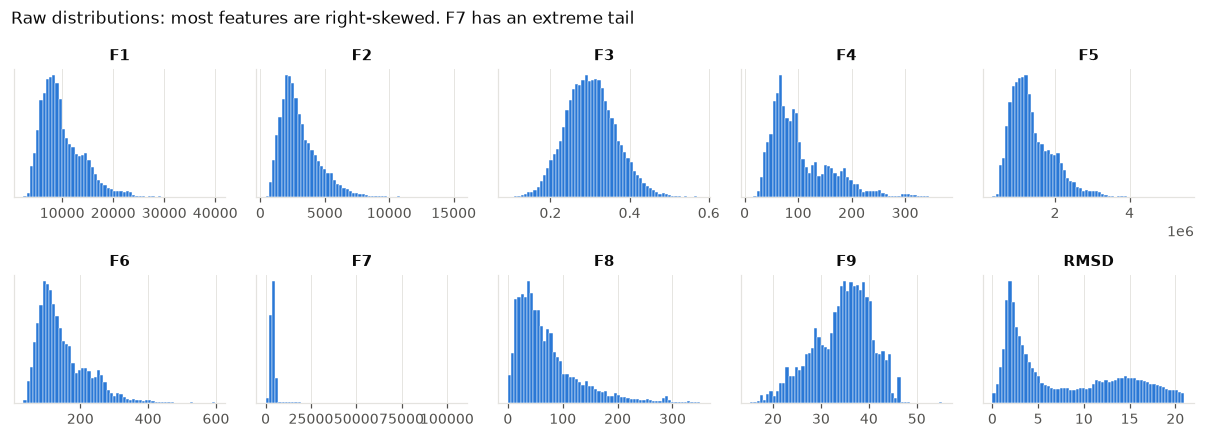

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
for ax, col in zip(axes.flat, FEATURES + [TARGET]):
    ax.hist(df[col], bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Raw distributions: most features are right-skewed. F7 has an extreme tail", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "raw_distributions", "eda")
plt.show()

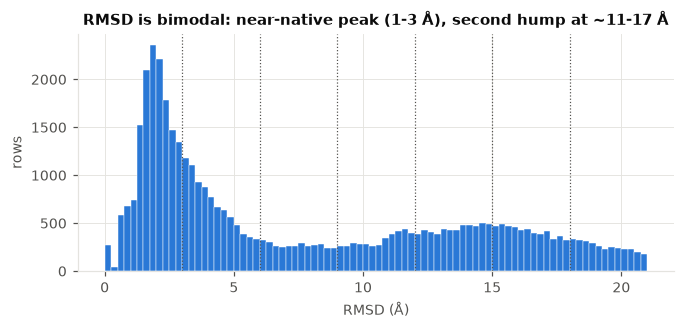

RMSD range: 0.00 to 21.00 Å, median 5.09 Å; rows with RMSD exactly 0: 272


In [5]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(df[TARGET], bins=np.arange(0, 21.25, 0.25), color=BLUE, edgecolor="white", linewidth=0.3)
for edge in RMSD_BIN_EDGES[1:-1]:
    ax.axvline(edge, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
ax.set_xlabel("RMSD (Å)")
ax.set_ylabel("rows")
ax.set_title("RMSD is bimodal: near-native peak (1-3 Å), second hump at ~11-17 Å")
plotting.save(fig, "rmsd_distribution", "eda")
plt.show()
print(f"RMSD range: {df[TARGET].min():.2f} to {df[TARGET].max():.2f} Å, median {df[TARGET].median():.2f} Å; "
      f"rows with RMSD exactly 0: {(df[TARGET] == 0).sum()}")

No missing or negative values. Seven features are right-skewed (skew > 1), and F7 has a very long right tail. The target is bounded (0 to 21 Å) and has two peaks. The dotted lines mark the 3 Å bins used for stratifying and for per-bin evaluation.

### 1.2 Splitting

- 80/20 train/test split, stratified on the 3 Å RMSD bins, with a fixed seed. The test set is only used at the end.
- All model comparisons use 5-fold stratified cross-validation (CV) on the training set.
- Inside each fold, 10% of the training part is kept aside for early stopping, so the stopping epoch is never chosen on the scored data.
- Limitation: there are no protein IDs, so decoys of the same protein can end up in both train and test. Scores may be slightly optimistic.

In [6]:
train_df, test_df = split_train_test(df)
print(f"train: {len(train_df)} rows | test: {len(test_df)} rows")

share = lambda d: pd.Series(np.bincount(rmsd_bin(d[TARGET]), minlength=7) / len(d), index=RMSD_BIN_LABELS)
(pd.DataFrame({"train %": share(train_df), "test %": share(test_df)}) * 100).round(2).T

train: 35215 rows | test: 8804 rows


,0-3,3-6,6-9,9-12,12-15,15-18,18-21
train %,34.34,18.80,7.48,8.87,12.14,11.34,7.03
test %,34.34,18.81,7.47,8.87,12.14,11.35,7.02


### 1.3 Feature relevance

Three checks on the training set:
1. Pearson and Spearman correlation with RMSD (linear and monotonic relationships).
2. Mutual information (MI), which detects any relationship. A column of random noise shows what "no relationship" looks like.
3. Redundancy between features.

In [7]:
from sklearn.feature_selection import mutual_info_regression

X_tr, y_tr = train_df[FEATURES], train_df[TARGET]
noise = pd.Series(np.random.default_rng(0).normal(size=len(X_tr)), name="NOISE (reference)")
X_with_noise = pd.concat([X_tr, noise], axis=1)

relevance = pd.DataFrame({
    "pearson": X_with_noise.corrwith(y_tr),
    "spearman": X_with_noise.corrwith(y_tr, method="spearman"),
    "mutual_info": mutual_info_regression(X_with_noise, y_tr, random_state=0),
})
relevance

,pearson,spearman,mutual_info
F1,-1.370e-02,-0.008,0.231
F2,1.587e-01,0.163,0.187
F3,3.750e-01,0.389,0.176
F4,-1.693e-01,-0.144,0.280
F5,-1.268e-02,-0.011,0.228
F6,-3.463e-02,-0.021,0.246
F7,-2.676e-03,-0.029,0.350
F8,-1.498e-04,0.073,0.243
F9,6.170e-02,0.061,0.297
NOISE (reference),1.292e-02,0.013,0.000


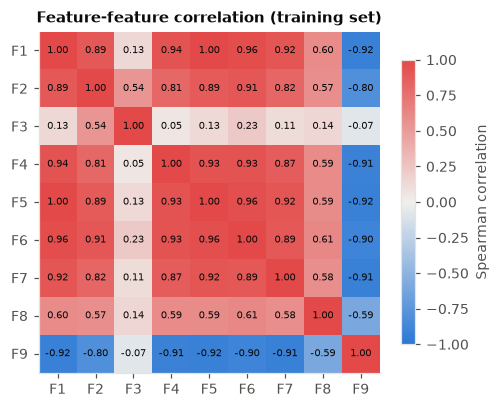

F5 / F1:        mean 138.5, coefficient of variation 0.026
F2 / (F1 × F3): mean 1.000, coefficient of variation 0.0000
MI(F5/F1 ratio, RMSD) = 0.089   vs noise 0.000


In [8]:
corr = X_tr.corr(method="spearman")
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(corr, cmap=plotting.DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.grid(False)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color=TEXT_PRIMARY)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman correlation")
ax.set_title("Feature-feature correlation (training set)")
plotting.save(fig, "feature_correlation", "eda")
plt.show()

ratio = X_tr["F5"] / X_tr["F1"]
print(f"F5 / F1:        mean {ratio.mean():.1f}, coefficient of variation {ratio.std() / ratio.mean():.3f}")
product = X_tr["F2"] / (X_tr["F1"] * X_tr["F3"])
print(f"F2 / (F1 × F3): mean {product.mean():.3f}, coefficient of variation {product.std() / product.mean():.4f}")

mi_ratio, mi_noise = mutual_info_regression(np.c_[ratio, noise], y_tr, random_state=0)
print(f"MI(F5/F1 ratio, RMSD) = {mi_ratio:.3f}   vs noise {mi_noise:.3f}")

Does leaving a feature out lose information? A gradient-boosted tree model is trained with 5-fold CV, leaving out one feature at a time.

In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

def cv_r2(columns):
    scores = []
    for fit_idx, val_idx in stratified_kfold(y_tr, k=5):
        model = HistGradientBoostingRegressor(random_state=0)
        model.fit(X_tr.iloc[fit_idx][columns], y_tr.iloc[fit_idx])
        scores.append(model.score(X_tr.iloc[val_idx][columns], y_tr.iloc[val_idx]))
    return np.mean(scores), np.std(scores)

base_mean, base_std = cv_r2(FEATURES)
rows = [{"left out": "(none)", "cv_r2": base_mean, "std": base_std, "change": 0.0}]
for f in FEATURES:
    m, s = cv_r2([c for c in FEATURES if c != f])
    rows.append({"left out": f, "cv_r2": m, "std": s, "change": m - base_mean})
m, s = cv_r2([c for c in FEATURES if c not in ("F2", "F5")])
rows.append({"left out": "F2 and F5 together", "cv_r2": m, "std": s, "change": m - base_mean})
drop_one = pd.DataFrame(rows).set_index("left out")
drop_one

,cv_r2,std,change
left out,,,
(none),0.546,0.009,0.000
F1,0.541,0.011,-0.005
F2,0.547,0.008,0.001
F3,0.540,0.010,-0.006
F4,0.491,0.007,-0.055
F5,0.543,0.011,-0.003
F6,0.525,0.011,-0.021
F7,0.529,0.009,-0.017
F8,0.493,0.007,-0.053


**Decision: drop F2 and keep 8 features.**
- No feature is uninformative: every MI is far above the noise column, even where the correlation is near zero. The relationships are non-linear.
- F2 = F1 × F3 exactly (non-polar area = total area × non-polar fraction). It adds nothing, so it is dropped.
- F5 ≈ 138.5 × F1, but not exactly. The ratio F5/F1 has MI 0.089, so F5 carries some extra information. Section 2.3 confirms the MLP does better with F5, so F5 is kept.
- F4 and F6 correlate strongly with F1 but are not functions of it, and removing them costs accuracy.

### 1.4 Outliers

On skewed data, outlier rules mostly flag the normal long tail. The counts below compare the raw features with the log-transformed features.

In [10]:
def outlier_counts(X):
    q1, q3 = X.quantile(0.25), X.quantile(0.75)
    iqr = q3 - q1
    z = (X - X.mean()) / X.std()
    return pd.DataFrame({
        "IQR rule (1.5)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum(),
        "|z| > 4": (z.abs() > 4).sum(),
    })

X_log = X_tr[INPUT_FEATURES].copy()
logged = [f for f in LOG_FEATURES if f in INPUT_FEATURES]
X_log[logged] = np.log1p(X_log[logged])
pd.concat({"raw": outlier_counts(X_tr[INPUT_FEATURES]), "after log1p": outlier_counts(X_log)}, axis=1)

raw            after log1p        
   IQR rule (1.5) |z| > 4 IQR rule (1.5) |z| > 4
F1            885      39             29       0
F3            295       7            295       7
F4            924      52              9       3
F5            821      38             19       0
F6            978      25             14       0
F7            411     150           1053     121
F8           1864     156            573       4
F9             95       0             95       0

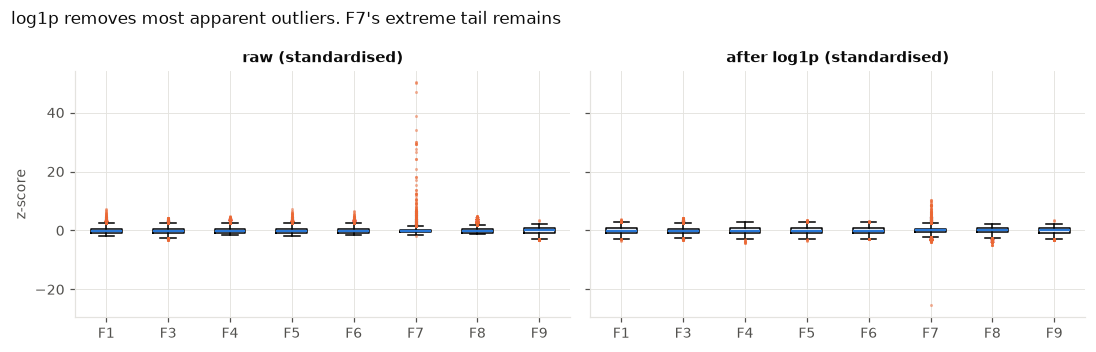

In [11]:
standardise = lambda X: (X - X.mean()) / X.std()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, X, title in [(axes[0], X_tr[INPUT_FEATURES], "raw (standardised)"),
                     (axes[1], X_log, "after log1p (standardised)")]:
    ax.boxplot(standardise(X).to_numpy(), tick_labels=INPUT_FEATURES, widths=0.5,
               flierprops=dict(marker=".", markersize=2, markeredgecolor=ORANGE, alpha=0.5),
               medianprops=dict(color=BLUE, linewidth=1.5))
    ax.set_title(title)
axes[0].set_ylabel("z-score")
fig.suptitle("log1p removes most apparent outliers. F7's extreme tail remains", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "outliers_before_after_log", "eda")
plt.show()

In [12]:
f7_extreme = X_tr["F7"] > X_tr["F7"].quantile(0.995)
print(f"F7 above its 99.5th percentile ({X_tr['F7'].quantile(0.995):.0f}): {f7_extreme.sum()} rows, "
      f"max {X_tr['F7'].max():.0f} vs median {X_tr['F7'].median():.0f}")
pd.DataFrame({
    "extreme-F7 rows": y_tr[f7_extreme].describe(),
    "all rows": y_tr.describe(),
}).T[["count", "mean", "25%", "50%", "75%"]]

F7 above its 99.5th percentile (11068): 177 rows, max 105948 vs median 3841


,count,mean,25%,50%,75%
extreme-F7 rows,177.0,8.657,3.174,5.951,13.857
all rows,35215.0,7.797,2.319,5.105,13.459


**Decision: log-transform and clip. Delete nothing.**
- After `log1p`, most outlier flags disappear. They were just the natural tail.
- F7 is the exception: its maximum is about 28× its median. Those rows have normal RMSD values, so they are kept.
- Every feature is clipped to its training 0.5th to 99.5th percentile, so extreme values cannot dominate.
- The target is never clipped. A large RMSD is a real bad structure.

### 1.5 Scaling

All features are continuous, so they all get the same treatment: `log1p` (skewed features only), clip, then standardise to mean 0 and standard deviation 1. The target is also standardised for training, and metrics are converted back to Å. Everything is fitted on the training data only.

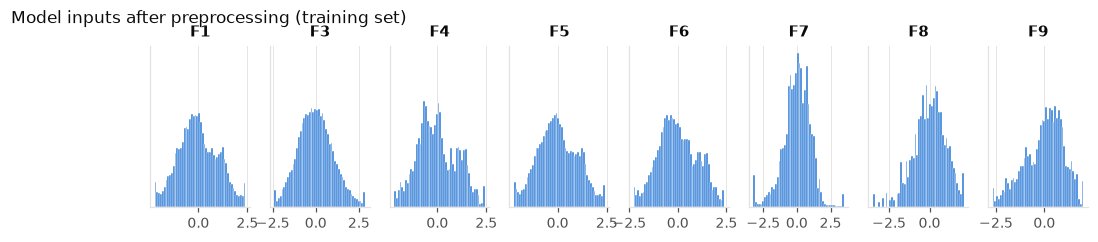

,F1,F3,F4,F5,F6,F7,F8,F9
mean,-6.500e-10,0.000,-1.300e-09,-1.300e-09,8.666e-10,0.000,2.167e-09,-6.500e-10
std,1.000e+00,1.000,1.000e+00,1.000e+00,1.000e+00,1.000,1.000e+00,1.000e+00
min,-2.227e+00,-2.399,-2.208e+00,-2.225e+00,-2.278e+00,-3.241,-3.489e+00,-2.668e+00
max,2.399e+00,2.863,2.425e+00,2.383e+00,2.389e+00,3.497,2.105e+00,2.016e+00


In [13]:
prep = Preprocessor().fit(train_df)
X_train = prep.transform_X(train_df)

fig, axes = plt.subplots(1, len(INPUT_FEATURES), figsize=(11, 1.9), sharey=True)
for i, (ax, col) in enumerate(zip(axes, INPUT_FEATURES)):
    ax.hist(X_train[:, i], bins=50, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Model inputs after preprocessing (training set)", x=0.01, ha="left", y=1.05)
plotting.save(fig, "preprocessed_distributions", "eda")
plt.show()

pd.DataFrame({"mean": X_train.mean(axis=0), "std": X_train.std(axis=0),
              "min": X_train.min(axis=0), "max": X_train.max(axis=0)}, index=INPUT_FEATURES).T

**Why standardise instead of min-max scaling?**
- Inputs on the same scale make gradient descent work better.
- Xavier and He initialisation assume inputs with unit variance.
- Sigmoid and tanh stay out of their flat regions.
- Min-max scaling depends on the extreme values, such as F7's maximum.

### 1.6 Imbalance

Some RMSD ranges are much more common than others. Below: training rows per RMSD bin.

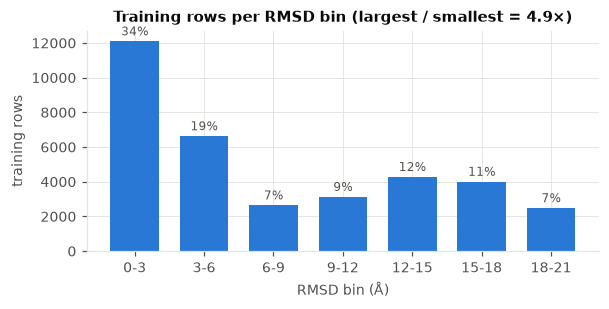

In [14]:
counts = pd.Series(np.bincount(rmsd_bin(y_tr), minlength=7), index=RMSD_BIN_LABELS)
fig, ax = plt.subplots(figsize=(6, 2.6))
bars = ax.bar(RMSD_BIN_LABELS, counts, color=BLUE, width=0.7)
ax.bar_label(bars, labels=[f"{c / counts.sum():.0%}" for c in counts], fontsize=8, color=TEXT_SECONDARY, padding=2)
ax.set_xlabel("RMSD bin (Å)")
ax.set_ylabel("training rows")
ax.set_title(f"Training rows per RMSD bin (largest / smallest = {counts.max() / counts.min():.1f}×)")
plotting.save(fig, "rmsd_bin_counts", "eda")
plt.show()

Why per-bin errors matter: a model that always predicts the mean, scored on one CV fold. Its overall RMSE hides very different errors per bin.

In [15]:
fit_idx, val_idx = next(stratified_kfold(y_tr, k=5))
y_val = y_tr.iloc[val_idx].to_numpy()
y_pred_mean = np.full_like(y_val, y_tr.iloc[fit_idx].mean())

print("overall:", {k: round(v, 3) for k, v in regression_metrics(y_val, y_pred_mean).items()})
per_bin_metrics(y_val, y_pred_mean)

overall: {'rmse': 6.131, 'mae': 5.501, 'r2': -0.0}


,n,rmse,mae,bias
bin,,,,
0-3,2419,5.930,5.895,5.895
3-6,1324,3.694,3.596,3.596
6-9,526,0.907,0.765,0.294
9-12,625,2.981,2.855,-2.855
12-15,855,5.813,5.746,-5.746
15-18,799,8.672,8.630,-8.630
18-21,495,11.604,11.570,-11.570


**How imbalance is handled**
- Training: stratified folds, so every fold has the same mix of RMSD values. Loss weighting is tested in section 2.4.
- Testing: the test set is stratified on the same bins.
- Evaluation: RMSE and bias are reported per bin as well as overall.

### 1.7 Summary

| Step | Decision |
|---|---|
| Cleaning | Remove 1,711 duplicate rows (44,019 left) |
| Splitting | 80/20 stratified split. 5-fold stratified CV on the training set. 10% of each fold for early stopping |
| Features | Drop F2 and keep 8 features |
| Outliers | `log1p` on skewed features, then clip to the 0.5th to 99.5th percentile |
| Scaling | Standardise the features and the target |
| Imbalance | Stratified splits and per-bin metrics |

## 2. MLP, training loop and baseline

| File | Purpose |
|---|---|
| `src/model.py` | The MLP |
| `src/schedules.py` | Learning-rate schedules, including warmup |
| `src/training.py` | Training loop with early stopping |
| `src/cv.py` | 5-fold cross-validation |

Every configuration uses the same folds.

In [16]:
from dataclasses import replace
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor

from src.cv import cross_validate, cross_validate_sklearn
from src.schedules import learning_rate
from src.training import TrainConfig
from src.plotting import AQUA, YELLOW

N_JOBS = 5
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

BASELINE = TrainConfig()
BASELINE

TrainConfig(hidden_sizes=(64, 64), activation='relu', init='auto', optimizer='adam', lr=0.001, batch_size=256, max_epochs=500, warmup_epochs=0.0, decay='constant', patience=20, weighted_loss=False, seed=0)

### 2.1 Learning-rate schedules

The learning rate is set before every step. Section 4 uses the warmup versions. Shown over 100 epochs with 5 warmup epochs.

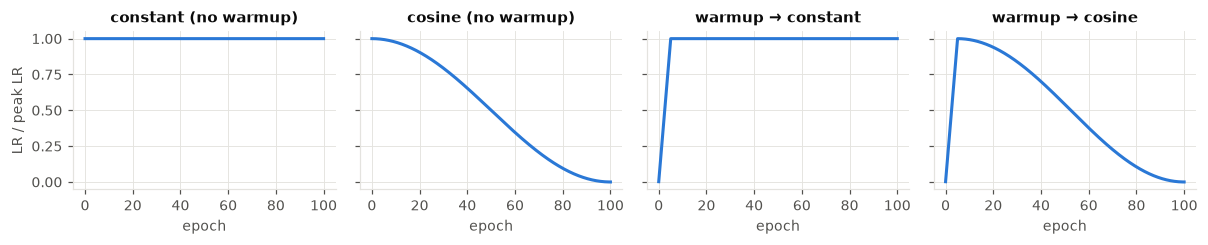

In [17]:
steps_per_epoch, epochs = 100, 100
total = steps_per_epoch * epochs
variants = [("constant (no warmup)", 0, "constant"), ("cosine (no warmup)", 0, "cosine"),
            ("warmup → constant", 5 * steps_per_epoch, "constant"), ("warmup → cosine", 5 * steps_per_epoch, "cosine")]

fig, axes = plt.subplots(1, 4, figsize=(11, 2.3), sharey=True)
for ax, (title, warmup, decay) in zip(axes, variants):
    lrs = [learning_rate(s, 1.0, total, warmup, decay) for s in range(total)]
    ax.plot(np.arange(total) / steps_per_epoch, lrs, color=BLUE)
    ax.set_title(title)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("LR / peak LR")
fig.tight_layout()
plotting.save(fig, "lr_schedules", "phase2")
plt.show()

### 2.2 Baseline

Hypothesis: the MLP beats linear regression, because the relationships are non-linear (section 1.3). It should be close to a gradient-boosted tree model.

The MLP is run with 3 seeds to show how much the random seed matters.

In [18]:
baselines = {
    "predict the mean": cross_validate_sklearn(DummyRegressor, train_df).summary(),
    "linear regression": cross_validate_sklearn(LinearRegression, train_df).summary(),
    "gradient boosting (reference)": cross_validate_sklearn(lambda: HistGradientBoostingRegressor(random_state=0), train_df).summary(),
}
mlp_runs = {seed: cross_validate(replace(BASELINE, seed=seed), train_df, n_jobs=N_JOBS) for seed in [0, 1, 2]}
for seed, res in mlp_runs.items():
    baselines[f"MLP 2x64 (seed {seed})"] = res.summary()

baseline_table = pd.DataFrame(baselines).T[["rmse_mean", "rmse_std", "mae_mean", "r2_mean", "r2_std", "best_epoch_mean"]]
baseline_table.to_csv(RESULTS / "phase2_baselines.csv")
baseline_table

,rmse_mean,rmse_std,mae_mean,r2_mean,r2_std,best_epoch_mean
predict the mean,6.136,0.005,5.515,-3.974e-06,3.718e-06,NaN
linear regression,5.185,0.045,4.247,2.860e-01,1.320e-02,NaN
gradient boosting (reference),4.134,0.044,3.123,5.462e-01,1.016e-02,NaN
MLP 2x64 (seed 0),4.088,0.060,3.022,5.562e-01,1.334e-02,141.8
MLP 2x64 (seed 1),4.095,0.022,3.029,5.547e-01,4.990e-03,136.0
MLP 2x64 (seed 2),4.086,0.047,3.017,5.566e-01,1.024e-02,171.6


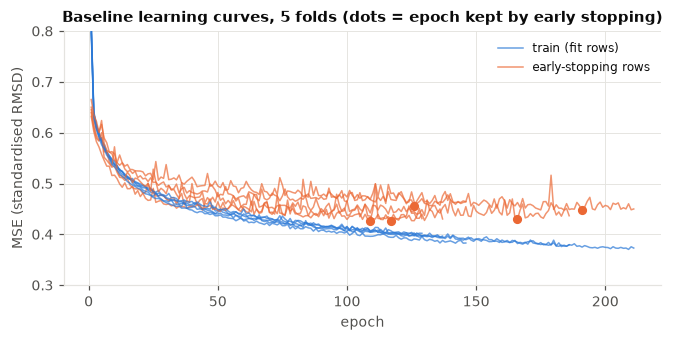

In [19]:
res = mlp_runs[0]
fig, ax = plt.subplots(figsize=(7, 3))
for fold, history in enumerate(res.histories):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], color=BLUE, linewidth=1, alpha=0.7, label="train (fit rows)" if fold == 0 else None)
    ax.plot(epochs, history["val_loss"], color=ORANGE, linewidth=1, alpha=0.7, label="early-stopping rows" if fold == 0 else None)
    best = res.folds.loc[fold, "best_epoch"]
    ax.plot(best, history["val_loss"][best - 1], "o", color=ORANGE, markersize=5)
ax.set_ylim(0.3, 0.8)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (standardised RMSD)")
ax.set_title("Baseline learning curves, 5 folds (dots = epoch kept by early stopping)")
ax.legend()
plotting.save(fig, "baseline_learning_curves", "phase2")
plt.show()

**Result: supported.**
- MLP: RMSE 4.08 to 4.10 Å (R² 0.555). Linear regression: 5.19 Å. Predicting the mean: 6.14 Å. Boosted trees: 4.13 Å.
- Changing the seed moves the RMSE by about 0.015 Å, and folds differ by 0.03 to 0.05 Å. Smaller differences than this are noise.
- The training loss keeps falling, but the early-stopping loss levels off after about 100 epochs. This is the start of overfitting, and early stopping keeps the best epoch.
- The MLP and the trees both stop at R² ≈ 0.55. This looked like a limit set by the features, but section 3.2 shows that larger networks do better.

### 2.3 Re-checking the feature choice with the MLP

Section 1.3 judged redundancy with a tree model. Here the MLP is run with 7, 8 and 9 features, with 5 seeds each. Each feature set is compared with the 7-feature set seed by seed.

In [20]:
feature_sets = {
    "7: drop F2 and F5": [c for c in FEATURES if c not in ("F2", "F5")],
    "8: drop F5 only": [c for c in FEATURES if c != "F5"],
    "8: drop F2 only (chosen)": INPUT_FEATURES,
    "9: all features": FEATURES,
}
feature_rmse = pd.DataFrame({
    name: [cross_validate(replace(BASELINE, seed=seed), train_df, features=cols, n_jobs=N_JOBS).summary()["rmse_mean"]
           for seed in range(5)]
    for name, cols in feature_sets.items()
})
feature_rmse.index.name = "seed"
feature_rmse.to_csv(RESULTS / "phase2_feature_sets.csv")

paired = feature_rmse.sub(feature_rmse.iloc[:, 0], axis=0)
pd.DataFrame({
    "cv_rmse_mean": feature_rmse.mean(),
    "std_over_seeds": feature_rmse.std(),
    "diff_vs_7_mean": paired.mean(),
    "seeds_better_than_7": (paired < 0).sum(),
})

,cv_rmse_mean,std_over_seeds,diff_vs_7_mean,seeds_better_than_7
7: drop F2 and F5,4.157,0.018,0.000,0
8: drop F5 only,4.148,0.015,-0.010,3
8: drop F2 only (chosen),4.098,0.014,-0.059,5
9: all features,4.118,0.010,-0.039,5


**Result**
- Adding F2 back changes nothing (+0.02 Å, within noise), so dropping F2 is confirmed.
- Dropping F5 costs about 0.06 Å in all 5 seeds, so F5 is kept.
- After `log1p`, the useful ratio becomes a difference, log F5 − log F1. An MLP computes a difference of two inputs easily, but a tree does not, which is why the tree check missed it.

### 2.4 Imbalance: does loss weighting help?

Hypothesis: weighting each row by the inverse frequency of its RMSD bin lowers the error in rare bins but raises the overall error.

Run with 3 seeds. Per-bin errors use each row's prediction from the fold where it was in the validation part.

In [21]:
weighted_runs = {seed: cross_validate(replace(BASELINE, seed=seed, weighted_loss=True), train_df, n_jobs=N_JOBS)
                 for seed in [0, 1, 2]}
pd.DataFrame({
    "unweighted": pd.concat([mlp_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
    "inverse-bin weighted": pd.concat([weighted_runs[s].summary() for s in [0, 1, 2]], axis=1).mean(axis=1),
}).T[["rmse_mean", "mae_mean", "r2_mean", "best_epoch_mean"]]

,rmse_mean,mae_mean,r2_mean,best_epoch_mean
unweighted,4.089,3.023,0.556,149.8
inverse-bin weighted,4.308,3.371,0.507,94.2


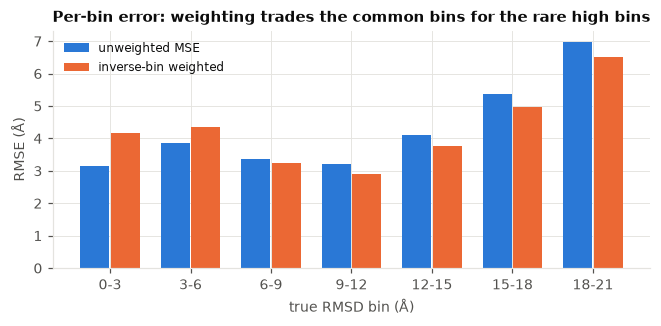

bin               0-3   3-6   6-9  9-12  12-15  15-18  18-21
unweighted rmse  3.15  3.86  3.37  3.22   4.11   5.39   6.97
           bias  1.95  2.27  1.32 -0.53  -2.38  -3.94  -5.58
weighted   rmse  4.16  4.36  3.24  2.91   3.77   4.96   6.50
           bias  2.84  2.79  1.44 -0.55  -2.35  -3.81  -5.41

In [22]:
def oof_per_bin(runs):
    """Per-bin RMSE and bias, averaged over seeds."""
    tables = [per_bin_metrics(r.predictions["y_true"], r.predictions["y_pred"]) for r in runs.values()]
    return pd.concat(tables).groupby(level=0, sort=False).mean()

bins_unweighted, bins_weighted = oof_per_bin(mlp_runs), oof_per_bin(weighted_runs)
per_bin_table = pd.concat({"unweighted": bins_unweighted[["rmse", "bias"]], "weighted": bins_weighted[["rmse", "bias"]]}, axis=1)
per_bin_table.to_csv(RESULTS / "phase2_loss_weighting_per_bin.csv")

x = np.arange(len(RMSD_BIN_LABELS))
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(x - 0.19, bins_unweighted["rmse"], width=0.36, color=BLUE, label="unweighted MSE")
ax.bar(x + 0.19, bins_weighted["rmse"], width=0.36, color=ORANGE, label="inverse-bin weighted")
ax.set_xticks(x, RMSD_BIN_LABELS)
ax.set_xlabel("true RMSD bin (Å)")
ax.set_ylabel("RMSE (Å)")
ax.set_title("Per-bin error: weighting trades the common bins for the rare high bins")
ax.legend()
plotting.save(fig, "loss_weighting_per_bin", "phase2")
plt.show()
per_bin_table.round(2).T

**Result: partly supported. Plain MSE is kept.**
- Weighting lowers the error in the five rarer bins by 0.13 to 0.47 Å, but raises it in the two most common bins (0-3 Å: +1.01 Å, 3-6 Å: +0.50 Å).
- Overall RMSE gets worse: 4.09 → 4.31 Å.
- The under-prediction of high RMSD barely changes (bias −5.6 → −5.4 Å). That error comes from the features, not the loss.

### 2.5 Baseline configuration

| Setting | Value |
|---|---|
| Inputs | 8 features |
| Architecture | 2 hidden layers of 64 units, ReLU, He initialisation |
| Optimiser | Adam, learning rate 0.001, batch size 256 |
| Loss | MSE on the standardised target |
| Stopping | Early stopping with patience 20, at most 500 epochs |

## 3. Core investigation

Each experiment changes one setting of the baseline. The hypotheses were written before the experiments ran.

Measured for every configuration (3 seeds × 5 folds):
- Final quality: CV RMSE in Å.
- Speed: epochs until the early-stopping MSE drops below 0.50 (predicting the mean gives 1.0).
- Stability: number of runs that diverged.

A difference only counts if it is larger than the noise and goes the same way in all 3 seeds.

Results are saved in `results/`. Set `RERUN = True` below to retrain everything (about 10 minutes on 12 cores).

In [23]:
from src.experiments import run_grid, aggregate, seeds_agree
from src.diagnostics import layer_gradient_sizes, SPEED_THRESHOLD
from src.model import MLP
from src.plotting import CATEGORICAL, TEXT_SECONDARY

RERUN = False

def plot_curves(ax, curves, labels, names=None, max_epoch=300):
    """Early-stopping MSE per epoch (averaged over folds and seeds), one line per configuration."""
    for colour, label in zip(CATEGORICAL, labels):
        c = curves[(curves["label"] == label) & (curves["epoch"] <= max_epoch)]
        ax.plot(c["epoch"], c["val_loss"], color=colour, linewidth=1.5, label=(names or {}).get(label, label))
    ax.axhline(SPEED_THRESHOLD, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
    ax.set_xlabel("epoch")
    ax.set_ylabel("early-stopping MSE")

### 3.1 Optimisers

SGD, SGD with momentum (0.9), RMSprop and Adam, each tested on the same grid of learning rates (0.0001 to 0.1).

- A1: Adam and RMSprop converge fastest, SGD slowest, and momentum in between.
- A2: at each optimiser's best learning rate, all four end within 0.05 Å.
- A3: Adam and RMSprop work over a wider range of learning rates. Momentum diverges at a lower learning rate than SGD, because its effective step is about 10× larger.

In [24]:
LRS = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
OPTIMISERS = ["sgd", "momentum", "rmsprop", "adam"]
opt_configs = {f"{opt} lr={lr:g}": replace(BASELINE, optimizer=opt, lr=lr) for opt in OPTIMISERS for lr in LRS}
opt_table, opt_curves = run_grid("optimisers", opt_configs, train_df, rerun=RERUN)

opt_summary = aggregate(opt_table, ["optimizer", "lr"])
opt_summary[["rmse", "rmse_seed_std", "epochs_to_0.50", "reached_0.50", "best_epoch", "diverged_folds"]].round(3)

rmse  rmse_seed_std  epochs_to_0.50 reached_0.50  \
optimizer lr                                                              
sgd       1.000e-04   4.928          0.032             NaN       0.0/15   
          3.000e-04   4.762          0.017             NaN       0.0/15   
          1.000e-03   4.525          0.024             NaN       0.0/15   
          3.000e-03   4.390          0.014         292.722       6.0/15   
          1.000e-02   4.469          0.054         112.000       3.0/15   
          3.000e-02   4.418          0.030          55.222       6.0/15   
          1.000e-01   4.438          0.037          44.500       3.0/15   
momentum  1.000e-04   4.522          0.023             NaN       0.0/15   
          3.000e-04   4.308          0.015         349.183      14.0/15   
          1.000e-03   4.210          0.019         118.133      15.0/15   
          3.000e-03   4.186          0.033          46.867      15.0/15   
          1.000e-02   4.078          0.035          20.267      15.0/15   
          3.000e-02   4.031          0.027          12.467      15.0/15   
          1.000e-01   5.778          0.489             NaN       0.0/15   
rmsprop   1.000e-04   4.251          0.005         159.067      15.0/15   
          3.000e-04   4.280          0.011          65.567      14.0/15   
          1.000e-03   4.311          0.031          32.556      11.0/15   
          3.000e-03   4.206          0.092          29.450      14.0/15   
          1.000e-02   4.349          0.076          36.700      10.0/15   
          3.000e-02   6.919          1.818             NaN       0.0/15   
          1.000e-01  55.126         20.293             NaN       0.0/15   
adam      1.000e-04   4.189          0.008         155.733      15.0/15   
          3.000e-04   4.143          0.004          55.733      15.0/15   
          1.000e-03   4.090          0.008          21.067      15.0/15   
          3.000e-03   4.039          0.021          12.400      15.0/15   
          1.000e-02   3.994          0.011           9.667      15.0/15   
          3.000e-02   4.206          0.016          18.400      15.0/15   
          1.000e-01   4.750          0.399             NaN       0.0/15   

                     best_epoch  diverged_folds  
optimizer lr                                     
sgd       1.000e-04     499.800             0.0  
          3.000e-04     499.200             0.0  
          1.000e-03     497.000             0.0  
          3.000e-03     322.400             0.0  
          1.000e-02      84.867             0.0  
          3.000e-02      50.600             0.0  
          1.000e-01      40.267             1.0  
momentum  1.000e-04     499.000             0.0  
          3.000e-04     490.400             0.0  
          1.000e-03     299.067             0.0  
          3.000e-03     144.600             0.0  
          1.000e-02     112.933             0.0  
          3.000e-02      92.333             0.0  
          1.000e-01      28.733             2.0  
rmsprop   1.000e-04     316.133             0.0  
          3.000e-04     105.733             0.0  
          1.000e-03      44.800             0.0  
          3.000e-03      54.533             0.0  
          1.000e-02      38.533             0.0  
          3.000e-02       4.200            11.0  
          1.000e-01       0.000            15.0  
adam      1.000e-04     481.600             0.0  
          3.000e-04     258.267             0.0  
          1.000e-03     154.000             0.0  
          3.000e-03      80.267             0.0  
          1.000e-02      77.867             0.0  
          3.000e-02      52.400             0.0  
          1.000e-01      36.267             0.0

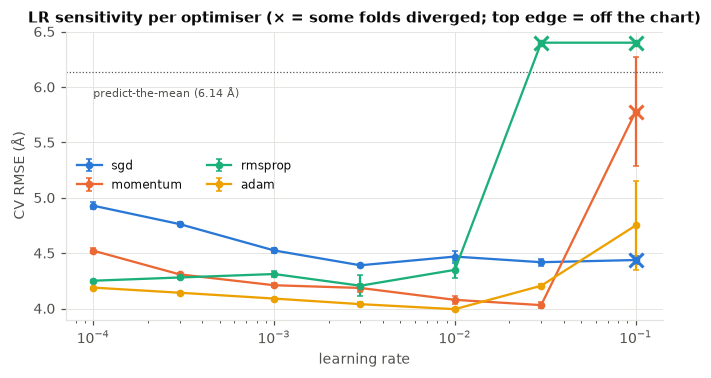

In [25]:
Y_TOP = 6.4
fig, ax = plt.subplots(figsize=(7, 3.4))
for colour, opt in zip(CATEGORICAL, OPTIMISERS):
    s = opt_summary.loc[opt]
    shown = s["rmse"].clip(upper=Y_TOP)
    ax.errorbar(s.index, shown, yerr=s["rmse_seed_std"].where(s["rmse"] < Y_TOP, 0), color=colour, marker="o",
                markersize=4, linewidth=1.5, capsize=2, label=opt)
    diverged = s["diverged_folds"] > 0
    ax.plot(s.index[diverged], shown[diverged], "x", color=colour, markersize=9, markeredgewidth=2)
ax.set_ylim(3.9, Y_TOP + 0.1)
ax.axhline(6.136, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
ax.text(1e-4, 6.0, "predict-the-mean (6.14 Å)", fontsize=7, color=TEXT_SECONDARY, va="top")
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("CV RMSE (Å)")
ax.set_title("LR sensitivity per optimiser (× = some folds diverged; top edge = off the chart)")
ax.legend(ncol=2, loc="center left")
plotting.save(fig, "optimisers_lr_sensitivity", "phase3")
plt.show()

In [26]:
best_lr = opt_summary["rmse"].groupby(level="optimizer", sort=False).idxmin()
best_rows = opt_summary.loc[best_lr.tolist()].copy()
overall_best = opt_summary["rmse"].min()
best_rows["lrs_near_own_best"] = [int((opt_summary.loc[o, "rmse"] <= opt_summary.loc[(o, lr), "rmse"] + 0.10).sum())
                                  for o, lr in best_lr]
best_rows["lrs_near_overall_best"] = [int((opt_summary.loc[o, "rmse"] <= overall_best + 0.10).sum()) for o, _ in best_lr]
best_rows[["rmse", "rmse_seed_std", "rmse_fold_std", "epochs_to_0.50", "reached_0.50", "best_epoch",
           "lrs_near_own_best", "lrs_near_overall_best"]].round(3)

,,rmse,rmse_seed_std,rmse_fold_std,epochs_to_0.50,reached_0.50,best_epoch,lrs_near_own_best,lrs_near_overall_best
optimizer,lr,,,,,,,,
sgd,0.003,4.390,0.014,0.057,292.722,6.0/15,322.400,4,0
momentum,0.030,4.031,0.027,0.040,12.467,15.0/15,92.333,2,2
rmsprop,0.003,4.206,0.092,0.082,29.450,14.0/15,54.533,3,0
adam,0.010,3.994,0.011,0.053,9.667,15.0/15,77.867,3,3


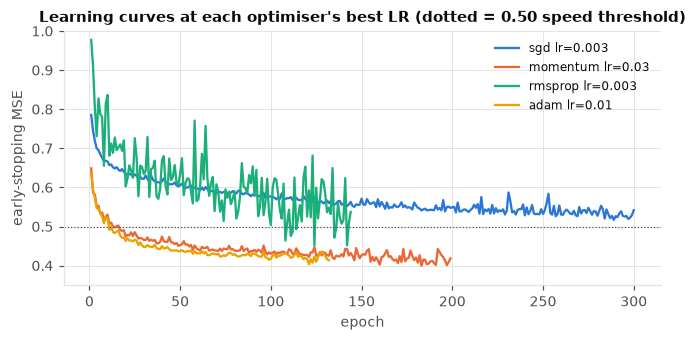

adam lr=0.01 vs sgd lr=0.003: mean diff -0.396 Å, adam lr=0.01 better in 3/3 seeds
adam lr=0.01 vs momentum lr=0.03: mean diff -0.037 Å, adam lr=0.01 better in 3/3 seeds
adam lr=0.01 vs rmsprop lr=0.003: mean diff -0.212 Å, adam lr=0.01 better in 3/3 seeds


In [27]:
best_labels = [f"{o} lr={lr:g}" for o, lr in best_lr]
fig, ax = plt.subplots(figsize=(7, 3))
plot_curves(ax, opt_curves, best_labels)
ax.set_ylim(0.35, 1.0)
ax.set_title("Learning curves at each optimiser's best LR (dotted = 0.50 speed threshold)")
ax.legend()
plotting.save(fig, "optimisers_learning_curves", "phase3")
plt.show()

for other in best_labels[:-1]:
    print(seeds_agree(opt_table, "label", best_labels[-1], other))

**Results** (each optimiser at its best learning rate)

| Optimiser | Best learning rate | CV RMSE | Epochs to 0.50 |
|---|---|---|---|
| Adam | 0.01 | 3.99 Å | 9.7 |
| Momentum | 0.03 | 4.03 Å | 12.5 |
| RMSprop | 0.003 | 4.21 Å | 29.5 |
| SGD | 0.003 | 4.39 Å | 293 |

- A1 partly supported: Adam is fastest and SGD slowest, but momentum beat RMSprop.
- A2 contradicted: results range from 3.99 to 4.39 Å. SGD is too slow to reach a good result within 500 epochs.
- A3 mixed: Adam handles the widest range of learning rates, but RMSprop handles the smallest (it diverges at 0.03 and above). Momentum fails at 0.1 while SGD still trains, as expected.
- Why RMSprop is fragile: its running average of squared gradients starts at zero, and PyTorch's RMSprop does not correct for this, so its first step is 10× the learning rate. Adam does correct for it. Oversized first steps are the problem that warmup addresses (section 4).
- Large learning rates also kill ReLU units: with Adam, 0.3% are dead at 0.001 and 48% at 0.1.

### 3.2 Architecture

1 to 4 hidden layers × 16, 64 or 256 units per layer. Everything else as the baseline.

- B1: going from 16 to 64 units clearly helps. Going from 64 to 256 helps by less than 0.05 Å.
- B2: 2 layers beat 1. More than 2 layers adds less than 0.05 Å.
- B3: larger networks overfit sooner, but early stopping stops them from ending up worse.

In [28]:
DEPTHS, WIDTHS = [1, 2, 3, 4], [16, 64, 256]
arch_configs = {f"{d}x{w}": replace(BASELINE, hidden_sizes=(w,) * d) for d in DEPTHS for w in WIDTHS}
arch_table, arch_curves = run_grid("architecture", arch_configs, train_df, rerun=RERUN)

arch_summary = aggregate(arch_table, ["depth", "width"])
arch_summary["params"] = [MLP(len(INPUT_FEATURES), (w,) * d).count_parameters() for d, w in arch_summary.index]
arch_summary[["params", "rmse", "rmse_seed_std", "epochs_to_0.50", "best_epoch", "gap_at_best", "dead_fraction"]].round(3)

params   rmse  rmse_seed_std  epochs_to_0.50  best_epoch  \
depth width                                                             
1     16        161  4.626          0.030             NaN     310.267   
      64        641  4.390          0.008         167.000     258.733   
      256      2561  4.230          0.015          74.333     179.133   
2     16        433  4.424          0.015         262.250     246.733   
      64       4801  4.090          0.008          21.067     154.000   
      256     68353  3.951          0.011          12.533      93.200   
3     16        705  4.331          0.020         119.083     227.733   
      64       8961  3.998          0.010          13.200     103.533   
      256    134145  3.831          0.019           7.133      65.200   
4     16        977  4.301          0.025          99.067     189.600   
      64      13121  3.965          0.016           8.600      66.133   
      256    199937  3.805          0.019           5.000      54.200   

             gap_at_best  dead_fraction  
depth width                              
1     16          -0.002          0.000  
      64           0.007          0.000  
      256          0.016          0.000  
2     16           0.006          0.004  
      64           0.044          0.003  
      256          0.083          0.022  
3     16           0.015          0.000  
      64           0.070          0.006  
      256          0.152          0.014  
4     16           0.020          0.015  
      64           0.085          0.004  
      256          0.188          0.009

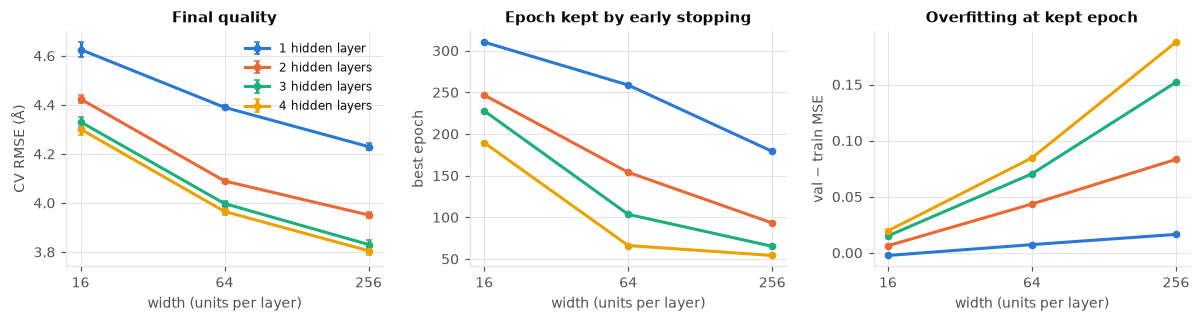

2x64 vs 2x16: mean diff -0.334 Å, 2x64 better in 3/3 seeds
2x256 vs 2x64: mean diff -0.139 Å, 2x256 better in 3/3 seeds
2x64 vs 1x64: mean diff -0.300 Å, 2x64 better in 3/3 seeds
4x64 vs 2x64: mean diff -0.124 Å, 4x64 better in 3/3 seeds
4x256 vs 2x64: mean diff -0.285 Å, 4x256 better in 3/3 seeds


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for colour, d in zip(CATEGORICAL, DEPTHS):
    s = arch_summary.loc[d]
    label = f"{d} hidden layer{'s' if d > 1 else ''}"
    axes[0].errorbar(WIDTHS, s["rmse"], yerr=s["rmse_seed_std"], color=colour, marker="o", markersize=4, capsize=2, label=label)
    axes[1].plot(WIDTHS, s["best_epoch"], color=colour, marker="o", markersize=4)
    axes[2].plot(WIDTHS, s["gap_at_best"], color=colour, marker="o", markersize=4)
for ax, title, ylabel in zip(axes, ["Final quality", "Epoch kept by early stopping", "Overfitting at kept epoch"],
                             ["CV RMSE (Å)", "best epoch", "val − train MSE"]):
    ax.set_xscale("log", base=2)
    ax.set_xticks(WIDTHS, [str(w) for w in WIDTHS])
    ax.set_xlabel("width (units per layer)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
axes[0].legend()
fig.tight_layout()
plotting.save(fig, "architecture", "phase3")
plt.show()

print(seeds_agree(arch_table, "label", "2x64", "2x16"))
print(seeds_agree(arch_table, "label", "2x256", "2x64"))
print(seeds_agree(arch_table, "label", "2x64", "1x64"))
print(seeds_agree(arch_table, "label", "4x64", "2x64"))
print(seeds_agree(arch_table, "label", "4x256", "2x64"))

**Results.** Every increase in width or depth helped, in all 3 seeds. The best network is 4 × 256: 3.81 Å, R² 0.615.

- B1 partly supported: 16 → 64 units gives −0.33 Å, and 64 → 256 still gives −0.14 Å.
- B2 half supported: 1 → 2 layers gives −0.30 Å, but 2 → 4 layers still gives −0.12 Å.
- B3 supported: the best epoch falls from 310 (1 × 16) to 54 (4 × 256), but the largest network is still the best.
- Depth is more efficient than width: 4 × 64 (13k weights) matches 2 × 256 (68k weights).
- B1 and B2 assumed the features limited performance. In fact the baseline was simply too small.

### 3.3 Activation functions

Sigmoid, tanh, ReLU and Leaky ReLU, each with its matching initialisation (Xavier for sigmoid and tanh, He for ReLU and Leaky ReLU). Tested with 2 and 4 hidden layers of 64 units.

- C1: ReLU and Leaky ReLU train fastest, then tanh, then sigmoid.
- C2: sigmoid gradients shrink towards the input layer (vanishing gradients), more so with depth. Adam should soften the effect on the final RMSE.
- C3: tanh, ReLU and Leaky ReLU end within 0.05 Å. Leaky ReLU gains nothing because few ReLU units die.

In [30]:
ACTIVATIONS = ["sigmoid", "tanh", "relu", "leaky_relu"]
act_configs = {f"{a} {d}x64": replace(BASELINE, activation=a, hidden_sizes=(64,) * d) for d in [2, 4] for a in ACTIVATIONS}
act_table, act_curves = run_grid("activations", act_configs, train_df, rerun=RERUN)

act_summary = aggregate(act_table, ["depth", "activation"])
act_summary[["rmse", "rmse_seed_std", "epochs_to_0.50", "reached_0.50", "best_epoch", "dead_fraction"]].round(3)

rmse  rmse_seed_std  epochs_to_0.50 reached_0.50  \
depth activation                                                      
2     sigmoid     4.344          0.018         423.317      11.0/15   
      tanh        4.063          0.041          64.133      15.0/15   
      relu        4.090          0.008          21.067      15.0/15   
      leaky_relu  4.095          0.017          21.200      15.0/15   
4     sigmoid     4.264          0.036         339.667      15.0/15   
      tanh        3.897          0.019          21.067      15.0/15   
      relu        3.965          0.016           8.600      15.0/15   
      leaky_relu  3.958          0.025           8.467      15.0/15   

                  best_epoch  dead_fraction  
depth activation                             
2     sigmoid        495.867            NaN  
      tanh           259.800            NaN  
      relu           154.000          0.003  
      leaky_relu     145.000          0.002  
4     sigmoid        481.067            NaN  
      tanh           120.933            NaN  
      relu            66.133          0.004  
      leaky_relu      85.467          0.000

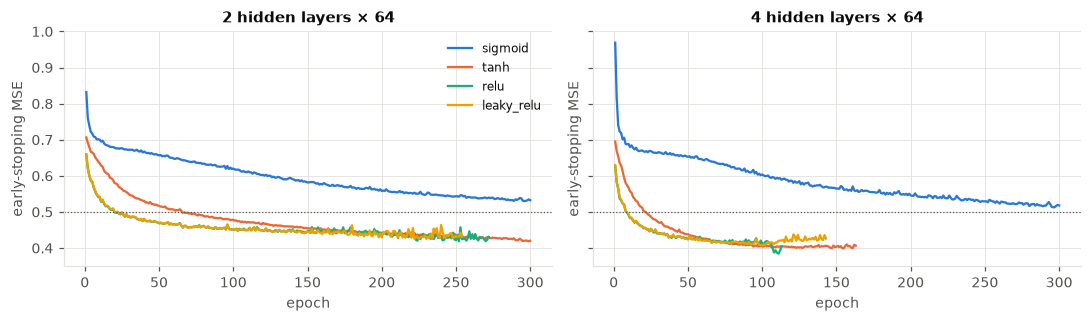

relu 2x64 vs sigmoid 2x64: mean diff -0.254 Å, relu 2x64 better in 3/3 seeds
relu 2x64 vs tanh 2x64: mean diff +0.027 Å, relu 2x64 better in 1/3 seeds
leaky_relu 2x64 vs relu 2x64: mean diff +0.005 Å, leaky_relu 2x64 better in 1/3 seeds
relu 4x64 vs sigmoid 4x64: mean diff -0.298 Å, relu 4x64 better in 3/3 seeds
relu 4x64 vs tanh 4x64: mean diff +0.068 Å, relu 4x64 better in 0/3 seeds
leaky_relu 4x64 vs relu 4x64: mean diff -0.008 Å, leaky_relu 4x64 better in 2/3 seeds


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, d in zip(axes, [2, 4]):
    plot_curves(ax, act_curves, [f"{a} {d}x64" for a in ACTIVATIONS], names={f"{a} {d}x64": a for a in ACTIVATIONS})
    ax.set_title(f"{d} hidden layers × 64")
    ax.set_ylim(0.35, 1.0)
axes[0].legend()
fig.tight_layout()
plotting.save(fig, "activations_learning_curves", "phase3")
plt.show()

for d in [2, 4]:
    print(seeds_agree(act_table, "label", f"relu {d}x64", f"sigmoid {d}x64"))
    print(seeds_agree(act_table, "label", f"relu {d}x64", f"tanh {d}x64"))
    print(seeds_agree(act_table, "label", f"leaky_relu {d}x64", f"relu {d}x64"))

Gradient check (C2): the average gradient size of each layer at initialisation, on 1,024 training rows, averaged over 10 initialisations. 8 layers are included to show the trend.

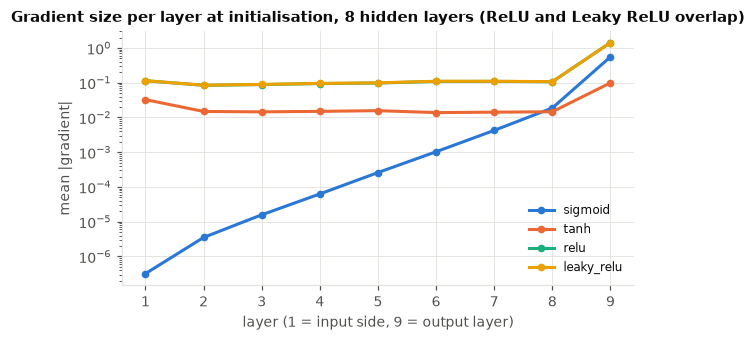

,depth 2: first ÷ last layer,depth 4: first ÷ last layer,depth 8: first ÷ last layer
sigmoid,0.003,2.000e-04,0.000
tanh,0.308,2.702e-01,0.329
relu,0.095,9.110e-02,0.080
leaky_relu,0.096,9.160e-02,0.081


In [32]:
import torch

prep_all = Preprocessor().fit(train_df)
batch = train_df.sample(1024, random_state=0)
X_batch, y_batch = prep_all.transform_X(batch), prep_all.transform_y(batch)

def gradient_profile(activation, depth, n_seeds=10):
    profiles = []
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        profiles.append(layer_gradient_sizes(MLP(len(INPUT_FEATURES), (64,) * depth, activation), X_batch, y_batch))
    return np.mean(profiles, axis=0)

ratios = pd.DataFrame({d: {a: (lambda p: p[0] / p[-1])(gradient_profile(a, d)) for a in ACTIVATIONS} for d in [2, 4, 8]})
ratios.columns = [f"depth {d}: first ÷ last layer" for d in [2, 4, 8]]

fig, ax = plt.subplots(figsize=(6, 3))
for colour, a in zip(CATEGORICAL, ACTIVATIONS):
    profile = gradient_profile(a, 8)
    ax.plot(range(1, len(profile) + 1), profile, color=colour, marker="o", markersize=4, label=a)
ax.set_yscale("log")
ax.set_xlabel("layer (1 = input side, 9 = output layer)")
ax.set_ylabel("mean |gradient|")
ax.set_title("Gradient size per layer at initialisation, 8 hidden layers (ReLU and Leaky ReLU overlap)")
ax.legend()
plotting.save(fig, "activations_gradient_flow", "phase3")
plt.show()
ratios.round(4)

**Results**
- C1 supported: with 4 layers, the epochs to 0.50 are 8.6 (ReLU), 21 (tanh) and 340 (sigmoid).
- C2 supported: with sigmoid, the gradient shrinks about 4× per layer, matching sigmoid's maximum slope of 0.25. With 8 layers, the first layer's gradient is about a million times smaller than the output layer's. tanh and ReLU stay flat. Adam rescales each step, so sigmoid still trains, just slowly.
- C3 partly supported: Leaky ReLU and ReLU perform the same (under 0.5% dead units), but tanh beat ReLU with 4 layers (3.90 vs 3.97 Å).

### 3.4 Setup for section 4

| Choice | Value | Reason |
|---|---|---|
| Architecture | 4 × 256 | Best result, with plenty of weights to prune |
| Activation | ReLU, He initialisation | Fastest, and standard in the pruning papers |
| Optimiser | SGD with momentum 0.9 | Has a clear learning rate where training breaks, which is what the warmup question is about. Used in the original papers |

### 3.5 Final test-set evaluation

The test set is used once, for the best configuration from cross-validation (4 × 256, ReLU, Adam, learning rate 0.001) and for the baseline. Each is trained on the full training set (10% kept for early stopping) with 5 seeds. New combinations of settings are not tried here, because that would mean choosing a model with the test set.

In [33]:
from src.final_evaluation import evaluate_on_test

final_configs = {"baseline 2x64": BASELINE, "best 4x256": replace(BASELINE, hidden_sizes=(256,) * 4)}
final_metrics, final_bins = evaluate_on_test(final_configs, train_df, test_df, rerun=RERUN)

prep_full = Preprocessor().fit(train_df)
reference = {}
for name, model in [("predict the mean", DummyRegressor()), ("linear regression", LinearRegression())]:
    model.fit(prep_full.transform_X(train_df), prep_full.transform_y(train_df).ravel())
    y_hat = prep_full.inverse_transform_y(model.predict(prep_full.transform_X(test_df)))
    reference[name] = regression_metrics(test_df[TARGET], y_hat)

summary = final_metrics.groupby("label")[["rmse", "mae", "r2"]].agg(["mean", "std"])
summary.columns = [f"{m}_{s}" for m, s in summary.columns]
pd.concat([pd.DataFrame(reference).T.rename(columns={"rmse": "rmse_mean", "mae": "mae_mean", "r2": "r2_mean"}), summary]).round(3)

,rmse_mean,mae_mean,r2_mean,rmse_std,mae_std,r2_std
predict the mean,6.143,5.523,-0.000,NaN,NaN,NaN
linear regression,5.191,4.257,0.286,NaN,NaN,NaN
baseline 2x64,4.048,2.953,0.566,0.043,0.060,0.009
best 4x256,3.780,2.599,0.621,0.026,0.048,0.005


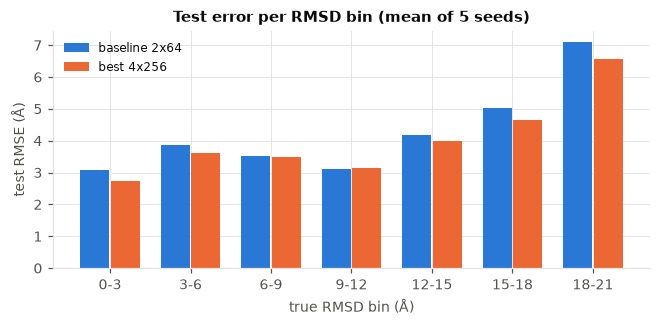

bin                     0-3      3-6     6-9    9-12    12-15   15-18   18-21
     label                                                                   
n                   3023.00  1656.00  658.00  781.00  1069.00  999.00  618.00
rmse baseline 2x64     3.08     3.86    3.52    3.11     4.18    5.04    7.09
     best 4x256        2.75     3.63    3.48    3.14     4.01    4.65    6.56
bias baseline 2x64     1.81     2.23    1.62   -0.31    -2.27   -3.50   -5.67
     best 4x256        1.34     1.82    1.60   -0.01    -1.66   -2.67   -4.82

In [34]:
test_bins = final_bins.groupby(["label", "bin"], sort=False)[["rmse", "bias"]].mean().unstack("label")
test_bins.insert(0, "n", final_bins.groupby("bin", sort=False)["n"].first())

x = np.arange(len(RMSD_BIN_LABELS))
fig, ax = plt.subplots(figsize=(7, 2.8))
for offset, (label, colour) in zip([-0.19, 0.19], [("baseline 2x64", BLUE), ("best 4x256", ORANGE)]):
    ax.bar(x + offset, test_bins[("rmse", label)], width=0.36, color=colour, label=label)
ax.set_xticks(x, RMSD_BIN_LABELS)
ax.set_xlabel("true RMSD bin (Å)")
ax.set_ylabel("test RMSE (Å)")
ax.set_title("Test error per RMSD bin (mean of 5 seeds)")
ax.legend()
plotting.save(fig, "final_test_per_bin", "phase3")
plt.show()
test_bins.round(2).T

**Results**
- Best model: test RMSE 3.78 ± 0.03 Å, R² 0.621. Baseline: 4.05 Å. Linear regression: 5.19 Å.
- Test and CV results agree (3.78 vs 3.81 Å), so the model choice did not overfit the CV folds.
- The error is lowest in the common 0-3 Å bin (2.75 Å) and highest in the rare 18-21 Å bin (6.56 Å). The model over-predicts low RMSD (+1.3 Å) and under-predicts high RMSD (−4.8 Å).

## 4. Research investigation: warmup and pruning

Question: does warmup make a network more robust to pruning, and is that because warmup allows a larger learning rate (η)?

The hypotheses and the rules for choosing the conditions were written before the experiments ran.

| Setup | |
|---|---|
| Network | 4 × 256, ReLU, He initialisation |
| Training | SGD with momentum 0.9, batch 256, 100 epochs, cosine decay to 0 |
| Warmup | Linear increase over the first 5 epochs |
| Data | Choices use a 10% validation split. Pruning results use the test set |
| Pruning | Remove the smallest weights across all layers (biases are kept) |
| Fine-tuning | The same for every network: η = 0.001 for 10 epochs, pruned weights kept at 0 |
| Seeds | 3 for step 1, 5 for the conditions |

In [35]:
from src.warmup_pruning import (prepare_data, lr_sweep, summarise_sweep, max_stable_lr, choose_conditions,
                                prune_and_finetune, paired_check, schedule, SPARSITIES)
from src.pruning import global_magnitude_masks
from src.training import train
from src.plotting import GREEN, VIOLET

wp_data = prepare_data(train_df, test_df)
COND_COLOURS = {"A": BLUE, "B": ORANGE, "C": AQUA}

### 4.1 Step 1: does warmup raise the usable learning rate? (H1)

H1: with warmup, the highest stable η is at least one grid step higher.

Stable means that no seed diverges and the validation RMSE is within 0.10 Å of that schedule's best.

In [36]:
sweep = lr_sweep(wp_data, rerun=RERUN)
sweep_summary = summarise_sweep(sweep)
table = sweep_summary.reset_index().pivot(index="lr", columns="warmup", values=["val_rmse", "diverged_seeds"])
table.columns = [f"{'warmup' if w else 'no warmup'}: {m}" for m, w in table.columns]
table.round(3)

,no warmup: val_rmse,warmup: val_rmse,no warmup: diverged_seeds,warmup: diverged_seeds
lr,,,,
0.005,3.732,3.680,0.0,0.0
0.010,3.804,3.625,2.0,0.0
0.020,NaN,3.631,3.0,0.0
0.030,NaN,3.656,3.0,0.0
0.050,NaN,3.714,3.0,0.0
0.100,NaN,3.710,3.0,0.0
0.200,NaN,3.730,3.0,0.0


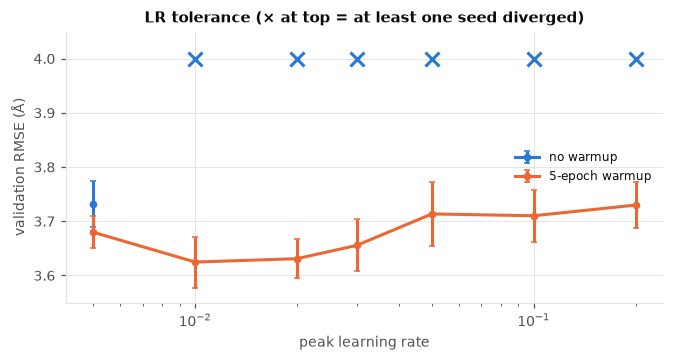

max stable LR  -  no warmup: 0.005 | warmup: 0.1
first-epoch divergences without warmup: 17 of 17 diverged runs


,warmup,peak LR
"A: no warmup, η0",False,0.005
"B: warmup, η1 > η0",True,0.2
"C: warmup, η0 (control)",True,0.005


In [37]:
Y_TOP = 4.0
fig, ax = plt.subplots(figsize=(7, 3.2))
for warmup, colour, name in [(False, BLUE, "no warmup"), (True, ORANGE, "5-epoch warmup")]:
    s = sweep_summary.loc[warmup]
    ok = s["diverged_seeds"] == 0
    ax.errorbar(s.index[ok], s["val_rmse"][ok], yerr=s["val_rmse_std"][ok].fillna(0), color=colour, marker="o",
                markersize=4, capsize=2, label=name)
    bad = s.index[s["diverged_seeds"] > 0]
    ax.plot(bad, [Y_TOP] * len(bad), "x", color=colour, markersize=9, markeredgewidth=2)
ax.set_xscale("log")
ax.set_ylim(3.55, Y_TOP + 0.05)
ax.set_xlabel("peak learning rate")
ax.set_ylabel("validation RMSE (Å)")
ax.set_title("LR tolerance (× at top = at least one seed diverged)")
ax.legend(loc="center right")
plotting.save(fig, "lr_tolerance", "phase4")
plt.show()

print("max stable LR  -  no warmup:", max_stable_lr(sweep_summary, False), "| warmup:", max_stable_lr(sweep_summary, True))
print("first-epoch divergences without warmup:", int((sweep[~sweep.warmup & sweep.diverged].diverged_at_epoch == 1).sum()),
      "of", int(sweep[~sweep.warmup].diverged.sum()), "diverged runs")

conditions = choose_conditions(sweep_summary)
A, B, C = list(conditions)
pd.DataFrame(conditions, index=["warmup", "peak LR"]).T

**Result: H1 supported.**
- Without warmup, the highest stable η is 0.005. At 0.01, 2 of 3 seeds diverge, and above that all do, always in the first epoch.
- With warmup, every run trains, up to η = 0.2. The usable learning rate is at least 20× higher.

Step 2: the rules then pick the three conditions:
- A: no warmup, η = 0.005
- B: warmup, η = 0.2 (the largest η whose validation RMSE is within 0.05 Å of A)
- C: warmup, η = 0.005 (the control)

### 4.2 Step 3: prune, fine-tune and compare (H2, H3)

Each condition is trained with 5 seeds, then pruned at each sparsity, tested, fine-tuned and tested again.

Δ = test RMSE after fine-tuning minus test RMSE before pruning. A smaller Δ means more robust.

- H2: B has a smaller Δ than A at 70% sparsity and above.
- H3: the benefit comes from the larger η, so B beats C, and C is about the same as A.

A difference counts if it holds in at least 4 of 5 seeds, at 2 or more of the high sparsities.

In [38]:
pruning = prune_and_finetune(wp_data, conditions, rerun=RERUN)

g = pruning.groupby(["condition", "sparsity"])
pruning_summary = pd.DataFrame({
    "before_ft": g["test_rmse_before_ft"].mean(), "after_ft": g["test_rmse_after_ft"].mean(),
    "after_ft_std": g["test_rmse_after_ft"].std(), "delta": g["delta"].mean(), "delta_std": g["delta"].std(),
})
pruning_summary.round(3).unstack(0).swaplevel(axis=1).sort_index(axis=1)

condition A: no warmup, η0                                          \
                  after_ft after_ft_std before_ft  delta delta_std   
sparsity                                                             
0.00                 3.844        0.025     3.813  0.031     0.008   
0.30                 3.847        0.022     4.354  0.034     0.013   
0.50                 3.893        0.017     5.689  0.081     0.023   
0.70                 4.119        0.011     7.971  0.306     0.030   
0.90                 4.522        0.008     8.585  0.710     0.029   
0.95                 4.761        0.021     7.511  0.949     0.040   
0.98                 5.150        0.067     6.744  1.337     0.076   

condition B: warmup, η1 > η0                                          \
                    after_ft after_ft_std before_ft  delta delta_std   
sparsity                                                               
0.00                   3.840        0.026     3.839  0.001     0.000   
0.30                   3.842        0.025     3.890  0.003     0.004   
0.50                   3.857        0.022     4.076  0.019     0.019   
0.70                   3.927        0.023     4.607  0.088     0.045   
0.90                   4.282        0.028     5.860  0.443     0.052   
0.95                   4.526        0.038     6.401  0.687     0.062   
0.98                   4.929        0.027     6.449  1.090     0.041   

condition C: warmup, η0 (control)                                          
                         after_ft after_ft_std before_ft  delta delta_std  
sparsity                                                                   
0.00                        3.802        0.015     3.775  0.026     0.013  
0.30                        3.808        0.012     4.603  0.033     0.014  
0.50                        3.885        0.021     6.154  0.110     0.019  
0.70                        4.120        0.017     7.390  0.345     0.020  
0.90                        4.514        0.024     7.823  0.739     0.032  
0.95                        4.784        0.020     7.152  1.009     0.021  
0.98                        5.175        0.069     6.687  1.399     0.067

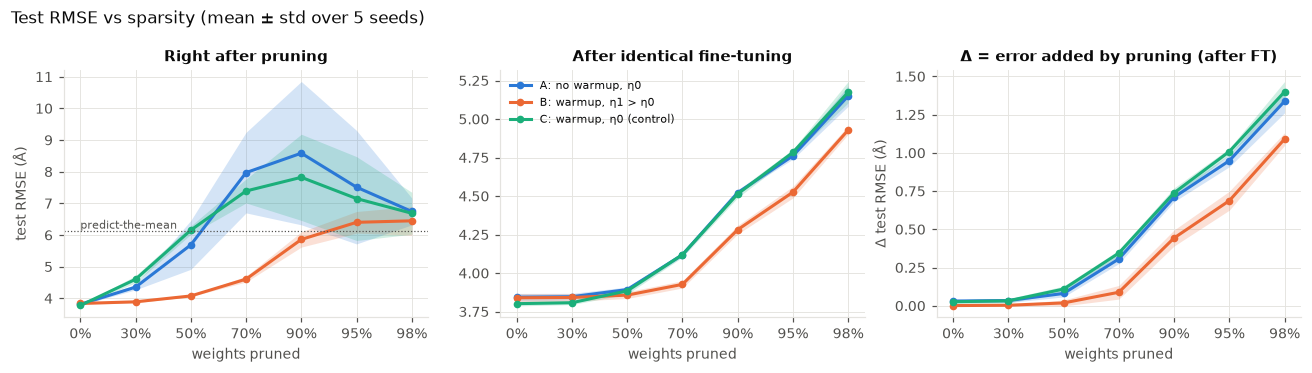

In [39]:
def sparsity_plot(results, metric, ax, names, colours, title):
    x = np.arange(len(SPARSITIES))
    for name in names:
        r = results[results["condition"] == name].groupby("sparsity")[metric]
        mean, std = r.mean().to_numpy(), r.std().to_numpy()
        ax.plot(x, mean, color=colours[name], marker="o", markersize=4, label=name)
        ax.fill_between(x, mean - std, mean + std, color=colours[name], alpha=0.2, linewidth=0)
    ax.set_xticks(x, [f"{s:.0%}" for s in SPARSITIES])
    ax.set_xlabel("weights pruned")
    ax.set_title(title)

colours = {A: BLUE, B: ORANGE, C: AQUA}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
sparsity_plot(pruning, "test_rmse_before_ft", axes[0], [A, B, C], colours, "Right after pruning")
sparsity_plot(pruning, "test_rmse_after_ft", axes[1], [A, B, C], colours, "After identical fine-tuning")
sparsity_plot(pruning, "delta", axes[2], [A, B, C], colours, "Δ = error added by pruning (after FT)")
axes[0].axhline(6.136, color=TEXT_SECONDARY, linewidth=0.8, linestyle=":")
axes[0].text(0, 6.2, "predict-the-mean", fontsize=7, color=TEXT_SECONDARY)
axes[0].set_ylabel("test RMSE (Å)")
axes[2].set_ylabel("Δ test RMSE (Å)")
axes[1].legend(loc="upper left", fontsize=7)
fig.suptitle("Test RMSE vs sparsity (mean ± std over 5 seeds)", x=0.01, ha="left")
fig.tight_layout()
plotting.save(fig, "pruning_vs_sparsity", "phase4")
plt.show()

In [40]:
for better, worse in [(B, A), (B, C), (C, A)]:
    print(f"\n{better}   vs   {worse}")
    print(paired_check(pruning, better, worse).round(3).to_string())


B: warmup, η1 > η0   vs   A: no warmup, η0
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity                                                        
0.70               -0.218             0.035          5/5    True
0.90               -0.267             0.050          5/5    True
0.95               -0.262             0.047          5/5    True
0.98               -0.247             0.104          5/5    True

B: warmup, η1 > η0   vs   C: warmup, η0 (control)
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity                                                        
0.70               -0.256             0.058          5/5    True
0.90               -0.295             0.037          5/5    True
0.95               -0.321             0.056          5/5    True
0.98               -0.309             0.071          5/5    True

C: warmup, η0 (control)   vs   A: no warmup, η0
          mean_delta_diff  seed_std_of_diff seeds_better  counts
sparsity   

In [41]:
pruning.groupby("condition")[["dense_val_rmse", "dense_test_rmse", "dead_fraction"]].agg(["mean", "std"]).round(3)

dense_val_rmse        dense_test_rmse         \
                                  mean    std            mean    std   
condition                                                              
A: no warmup, η0                 3.740  0.030           3.813  0.025   
B: warmup, η1 > η0               3.728  0.032           3.839  0.024   
C: warmup, η0 (control)          3.683  0.020           3.775  0.013   

                        dead_fraction         
                                 mean    std  
condition                                     
A: no warmup, η0                0.036  0.039  
B: warmup, η1 > η0              0.002  0.001  
C: warmup, η0 (control)         0.000  0.000

**Results: H2 and H3 supported.**
- A and B start with the same accuracy (validation 3.74 vs 3.73 Å), but B loses 0.22 to 0.27 Å less after pruning, in all 5 seeds at every sparsity from 70%.
- Before fine-tuning the gap is large: at 70% sparsity B scores 4.6 Å, while A and C jump to 8.0 and 7.4 Å.
- C is no better than A. Warmup alone does not help. Only the larger η does.
- Other explanations were checked. B has the fewest dead units (0.2% vs 3.6% for A), and the fine-tuning η favours A and C, not B.

### 4.3 Why is B more robust? (added after seeing the results)

Magnitude pruning removes the smallest weights. If a network keeps more of its weight in a few large weights, removing the small ones costs less. Below: weight sizes for one network per condition (seed 0).

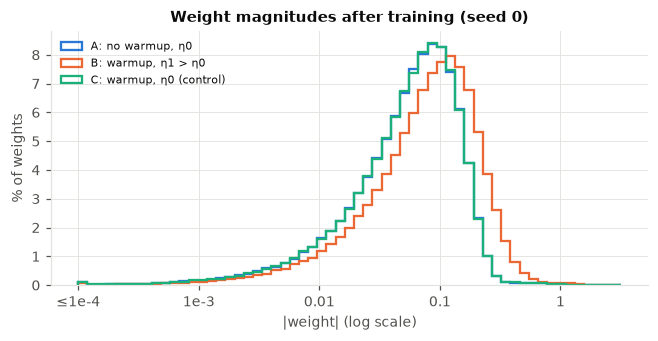

,median |w|,share of Σw² in top 10 %,share of Σw² in top 30 %
"A: no warmup, η0",0.062,0.564,0.833
"B: warmup, η1 > η0",0.084,0.608,0.857
"C: warmup, η0 (control)",0.062,0.564,0.833


In [42]:
def trained_weights(warmup, lr, seed=0):
    model = train(schedule(warmup, lr, seed), wp_data.X_fit, wp_data.y_fit, wp_data.X_val, wp_data.y_val).model
    return torch.cat([layer.weight.detach().abs().flatten() for layer in model.linear_layers()]).numpy()

weights = {name: trained_weights(*spec) for name, spec in conditions.items()}

def top_share(w, fraction):
    w2 = np.sort(w ** 2)[::-1]
    return w2[: int(fraction * len(w2))].sum() / w2.sum()

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(-4, 0.5, 60)
for name, w in weights.items():
    log_w = np.clip(np.log10(w + 1e-12), bins[0], bins[-1])
    ax.hist(log_w, bins=bins, histtype="step", linewidth=1.5, color=colours[name], label=name,
            weights=np.full(len(w), 100 / len(w)))
ax.set_xticks([-4, -3, -2, -1, 0], ["≤1e-4", "1e-3", "0.01", "0.1", "1"])
ax.set_xlabel("|weight| (log scale)")
ax.set_ylabel("% of weights")
ax.set_title("Weight magnitudes after training (seed 0)")
ax.legend(fontsize=7, loc="upper left")
plotting.save(fig, "weight_magnitudes", "phase4")
plt.show()

pd.DataFrame({name: {"median |w|": np.median(w), "share of Σw² in top 10 %": top_share(w, 0.10),
                     "share of Σw² in top 30 %": top_share(w, 0.30)} for name, w in weights.items()}).T.round(4)

**Result.** A and C have almost the same weight distribution. B's weights are larger, and its largest 10% of weights hold more of the total (60.6% vs 56.5% of Σw²). This may explain part of B's robustness. It is an exploration, not a test.

### 4.4 Extensions

1. Learning-rate rewinding instead of fine-tuning: each pruned network is retrained with its own original schedule and peak η. Prediction: better recovery for all, and a smaller gap between A and B. Here Δ is measured against each network's own retrained unpruned version, because the extra training also improves unpruned networks.
2. Warmup duration: condition B with 1, 5 or 15 warmup epochs. Prediction: once training is stable, a longer warmup adds nothing.

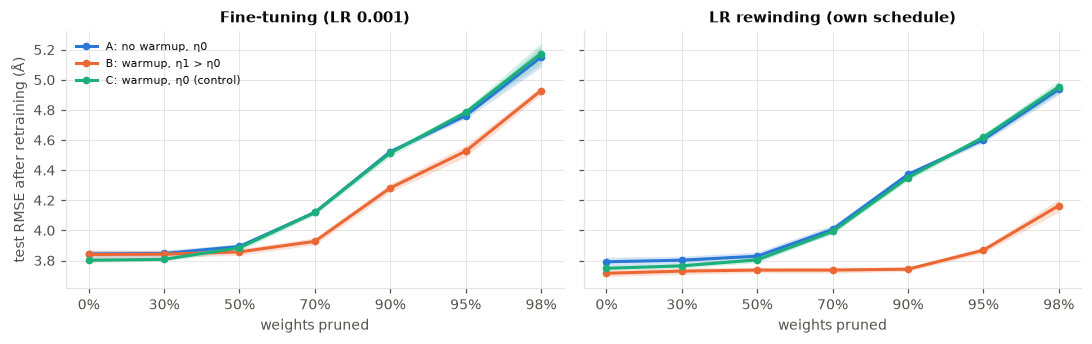

Retrained dense (0 %) test RMSE: {'A: no warmup, η0': 3.792, 'B: warmup, η1 > η0': 3.715, 'C: warmup, η0 (control)': 3.748}

Δ vs the retrained dense network (Å):
                 fine-tune                                                   LR rewind                                           
condition A: no warmup, η0 B: warmup, η1 > η0 C: warmup, η0 (control) A: no warmup, η0 B: warmup, η1 > η0 C: warmup, η0 (control)
sparsity                                                                                                                         
0.70                 0.275              0.087                   0.318            0.215              0.021                   0.245
0.90                 0.679              0.442                   0.712            0.580              0.027                   0.601
0.95                 0.918              0.686                   0.982            0.810              0.153                   0.871
0.98                 1.306              1.089            

In [43]:
rewind = prune_and_finetune(wp_data, conditions, retrain="lr_rewind", cache_name="phase4_ext_lr_rewind", rerun=RERUN)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
sparsity_plot(pruning, "test_rmse_after_ft", axes[0], [A, B, C], colours, "Fine-tuning (LR 0.001)")
sparsity_plot(rewind, "test_rmse_after_ft", axes[1], [A, B, C], colours, "LR rewinding (own schedule)")
axes[0].set_ylabel("test RMSE after retraining (Å)")
axes[0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plotting.save(fig, "ext_lr_rewinding", "phase4")
plt.show()

def delta_vs_retrained_dense(results):
    ref = results[results["sparsity"] == 0].set_index(["condition", "seed"])["test_rmse_after_ft"]
    keys = pd.MultiIndex.from_frame(results[["condition", "seed"]])
    return results.assign(delta=results["test_rmse_after_ft"].to_numpy() - ref.reindex(keys).to_numpy())

print("Retrained dense (0 %) test RMSE:", rewind[rewind.sparsity == 0].groupby("condition")["test_rmse_after_ft"].mean().round(3).to_dict())
rewind_table = pd.concat({"fine-tune": delta_vs_retrained_dense(pruning).groupby(["sparsity", "condition"])["delta"].mean(),
                "LR rewind": delta_vs_retrained_dense(rewind).groupby(["sparsity", "condition"])["delta"].mean()},
               axis=1).unstack("condition")
print("\nΔ vs the retrained dense network (Å):")
print(rewind_table.loc[[0.7, 0.9, 0.95, 0.98]].round(3).to_string())
print(f"\nLR rewinding: {B} vs {A}")
print(paired_check(delta_vs_retrained_dense(rewind), B, A).round(3).to_string())

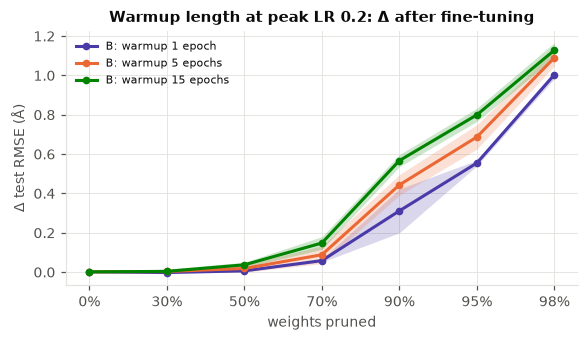

sparsity,dense test RMSE,0.7,0.9,0.95,0.98
condition,,,,,
B: warmup 1 epoch,3.872,0.059,0.312,0.555,1.004
B: warmup 15 epochs,3.791,0.148,0.567,0.800,1.129
B: warmup 5 epochs,3.839,0.088,0.443,0.687,1.090


In [44]:
eta1 = conditions[B][1]
durations = {f"B: warmup {w} epoch{'s' if w > 1 else ''}": (True, eta1, w) for w in [1, 5, 15]}
duration = prune_and_finetune(wp_data, durations, cache_name="phase4_ext_warmup_duration", rerun=RERUN)

dur_colours = dict(zip(durations, [VIOLET, ORANGE, GREEN]))
fig, ax = plt.subplots(figsize=(6, 3))
sparsity_plot(duration, "delta", ax, list(durations), dur_colours, f"Warmup length at peak LR {eta1:g}: Δ after fine-tuning")
ax.set_ylabel("Δ test RMSE (Å)")
ax.legend(fontsize=7)
plotting.save(fig, "ext_warmup_duration", "phase4")
plt.show()

d = duration.groupby(["condition", "sparsity"])["delta"].mean().unstack("sparsity")[[0.7, 0.9, 0.95, 0.98]]
d.insert(0, "dense test RMSE", duration.groupby("condition")["dense_test_rmse"].mean())
d.round(3)

3. Robustness across all warmup learning rates (not planned in advance). H3 rests on two values of η. If the larger η causes the robustness, Δ should fall steadily as η grows. All 7 warmup values from step 1 are tested with 5 seeds.

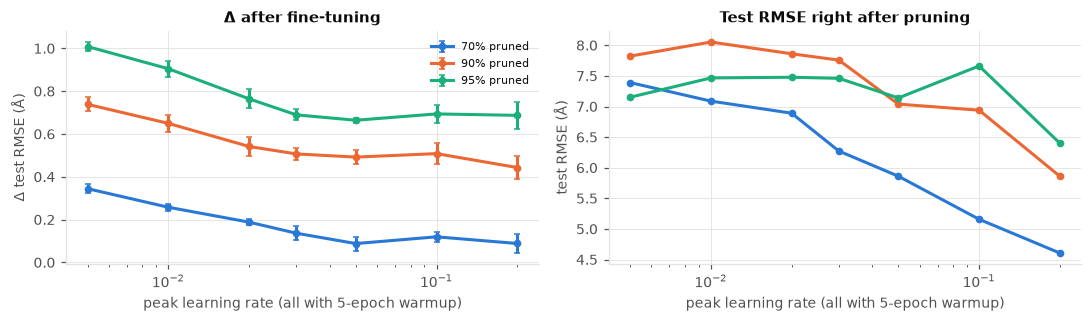

Spearman rank correlation between LR and Δ (all 35 runs): {'70%': np.float64(-0.88), '90%': np.float64(-0.8), '95%': np.float64(-0.78), '98%': np.float64(-0.7)}


sparsity,unpruned test RMSE,0.7,0.9,0.95,0.98,before FT @70%
lr,,,,,,
0.005,3.775,0.345,0.739,1.009,1.399,7.390
0.010,3.758,0.258,0.650,0.905,1.295,7.088
0.020,3.790,0.188,0.542,0.764,1.142,6.891
0.030,3.819,0.136,0.507,0.689,1.033,6.272
0.050,3.843,0.088,0.492,0.664,0.968,5.862
0.100,3.838,0.120,0.508,0.694,0.999,5.158
0.200,3.839,0.088,0.443,0.687,1.090,4.607


In [45]:
dose = prune_and_finetune(wp_data, {f"warmup lr={lr:g}": (True, lr) for lr in sorted(sweep.lr.unique())},
                          cache_name="phase4_ext_lr_dose", rerun=RERUN)
dose_table = dose.groupby(["lr", "sparsity"])["delta"].mean().unstack("sparsity")[[0.7, 0.9, 0.95, 0.98]]
dose_table.insert(0, "unpruned test RMSE", dose.groupby("lr")["dense_test_rmse"].mean())
dose_table["before FT @70%"] = dose[dose.sparsity == 0.7].groupby("lr")["test_rmse_before_ft"].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for colour, s_ in zip([BLUE, ORANGE, AQUA], [0.7, 0.9, 0.95]):
    g = dose[dose.sparsity == s_].groupby("lr")["delta"]
    axes[0].errorbar(g.mean().index, g.mean(), yerr=g.std(), color=colour, marker="o", markersize=4, capsize=2, label=f"{s_:.0%} pruned")
    g2 = dose[dose.sparsity == s_].groupby("lr")["test_rmse_before_ft"]
    axes[1].plot(g2.mean().index, g2.mean(), color=colour, marker="o", markersize=4, label=f"{s_:.0%} pruned")
for ax, title, ylabel in zip(axes, ["Δ after fine-tuning", "Test RMSE right after pruning"], ["Δ test RMSE (Å)", "test RMSE (Å)"]):
    ax.set_xscale("log")
    ax.set_xlabel("peak learning rate (all with 5-epoch warmup)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
axes[0].legend(fontsize=7)
fig.tight_layout()
plotting.save(fig, "ext_lr_dose_response", "phase4")
plt.show()

print("Spearman rank correlation between LR and Δ (all 35 runs):",
      {f"{s_:.0%}": round(dose[dose.sparsity == s_][["lr", "delta"]].corr(method="spearman").iloc[0, 1], 2) for s_ in [0.7, 0.9, 0.95, 0.98]})
dose_table.round(3)

**Results**
1. Learning-rate rewinding: recovery improves for all, but the gap between A and B grows (at 90% sparsity, B loses 0.03 Å and A loses 0.58 Å). The prediction was wrong. Each network retrains at its own η, and B's large η recovers better.
2. Warmup duration: 1 epoch of warmup is already enough to train at η = 0.2. 1 and 5 epochs give similar robustness. 15 epochs is less robust, perhaps because less time is spent at the large η.
3. All warmup learning rates: Δ at 70% falls from 0.35 Å (η = 0.005) to 0.09 Å (η = 0.05 and 0.2), with a Spearman correlation of −0.88. The most accurate unpruned model (η = 0.01) is not the most robust. Robustness follows η, not accuracy.

### 4.5 Conclusion

- The effect was observed: at the same starting accuracy, the network trained with warmup lost much less accuracy after pruning.
- Both links of the mechanism are supported:
  1. Warmup makes a much larger η usable (H1).
  2. The larger η, not warmup itself, gives the robustness (H3 and extension 3).
- So warmup helps pruning robustness indirectly, by allowing a larger learning rate.

Limitations: one dataset and an MLP only, one-shot pruning, a single validation split, and B's η at the top of the grid.

## 5. Figures for the report

Combined versions of the figures above, saved to `figures/report/`. No new results.

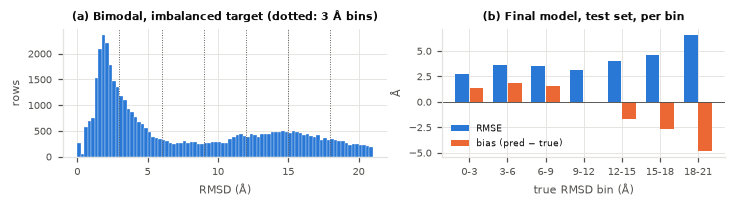

In [46]:
from src.plotting import MAGENTA
REPORT_DIR = plotting.FIGURES_DIR / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
small = {"font.size": 7, "axes.titlesize": 7.5, "axes.labelsize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
         "legend.fontsize": 6, "lines.linewidth": 1.4, "lines.markersize": 3}

def decimal_lr_axis(ax, ticks):
    """Log-scale LR axis labelled with plain decimals (0.001, not 10^-3)."""
    ax.set_xticks(ticks, [f"{t:g}" for t in ticks])
    ax.xaxis.set_minor_formatter(plt.NullFormatter())

def save_report(fig, name):
    fig.savefig(REPORT_DIR / f"{name}.pdf")
    fig.savefig(REPORT_DIR / f"{name}.png")

with plt.rc_context(small):
    fig, axes = plt.subplots(1, 2, figsize=(6.7, 1.9), gridspec_kw={"width_ratios": [1.15, 1]})
    axes[0].hist(df[TARGET], bins=np.arange(0, 21.25, 0.25), color=BLUE, edgecolor="white", linewidth=0.2)
    for edge in RMSD_BIN_EDGES[1:-1]:
        axes[0].axvline(edge, color=TEXT_SECONDARY, linewidth=0.6, linestyle=":")
    axes[0].set(xlabel="RMSD (Å)", ylabel="rows", title="(a) Bimodal, imbalanced target (dotted: 3 Å bins)")
    x = np.arange(len(RMSD_BIN_LABELS))
    best_bins = final_bins[final_bins.label == "best 4x256"].groupby("bin", sort=False)[["rmse", "bias"]].mean()
    axes[1].bar(x - 0.19, best_bins["rmse"], width=0.36, color=BLUE, label="RMSE")
    axes[1].bar(x + 0.19, best_bins["bias"], width=0.36, color=ORANGE, label="bias (pred − true)")
    axes[1].axhline(0, color=TEXT_SECONDARY, linewidth=0.6)
    axes[1].set_xticks(x, RMSD_BIN_LABELS)
    axes[1].set(xlabel="true RMSD bin (Å)", ylabel="Å", title="(b) Final model, test set, per bin")
    axes[1].legend(loc="lower left")
    fig.tight_layout()
    save_report(fig, "fig1_data")
    plt.show()

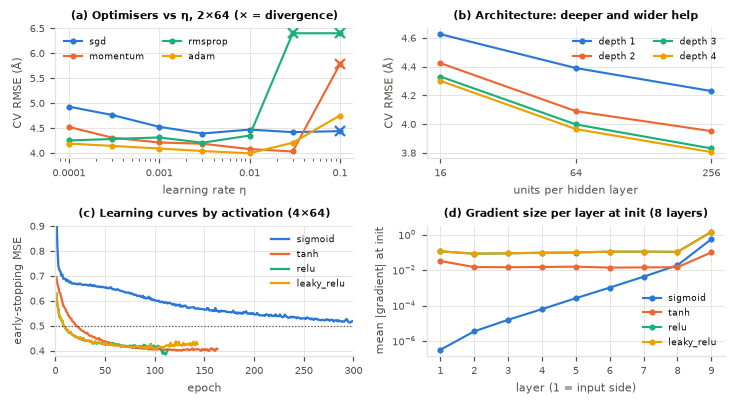

In [47]:
with plt.rc_context(small):
    fig, axes = plt.subplots(2, 2, figsize=(6.7, 3.7))
    ax = axes[0, 0]
    for colour, opt in zip(CATEGORICAL, OPTIMISERS):
        s = opt_summary.loc[opt]
        shown = s["rmse"].clip(upper=6.4)
        ax.plot(s.index, shown, color=colour, marker="o", label=opt)
        bad = s["diverged_folds"] > 0
        ax.plot(s.index[bad], shown[bad], "x", color=colour, markersize=6, markeredgewidth=1.5)
    ax.set(xscale="log", ylim=(3.9, 6.5), xlabel="learning rate η", ylabel="CV RMSE (Å)",
           title="(a) Optimisers vs η, 2×64 (× = divergence)")
    decimal_lr_axis(ax, [0.0001, 0.001, 0.01, 0.1])
    ax.legend(ncol=2, loc="upper left")

    ax = axes[0, 1]
    for colour, d in zip(CATEGORICAL, DEPTHS):
        ax.plot(WIDTHS, arch_summary.loc[d]["rmse"], color=colour, marker="o", label=f"depth {d}")
    ax.set_xscale("log", base=2)
    ax.set_xticks(WIDTHS, [str(w) for w in WIDTHS])
    ax.set(xlabel="units per hidden layer", ylabel="CV RMSE (Å)", title="(b) Architecture: deeper and wider help")
    ax.legend(ncol=2, loc="upper right")

    ax = axes[1, 0]
    plot_curves(ax, act_curves, [f"{a} 4x64" for a in ACTIVATIONS], names={f"{a} 4x64": a for a in ACTIVATIONS})
    ax.set(ylim=(0.38, 0.9), xlim=(0, 300), title="(c) Learning curves by activation (4×64)")
    ax.legend()

    ax = axes[1, 1]
    for colour, a in zip(CATEGORICAL, ACTIVATIONS):
        profile = gradient_profile(a, 8)
        ax.plot(range(1, len(profile) + 1), profile, color=colour, marker="o", label=a)
    ax.set(yscale="log", xlabel="layer (1 = input side)", ylabel="mean |gradient| at init",
           title="(d) Gradient size per layer at init (8 layers)")
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_report(fig, "fig2_core")
    plt.show()

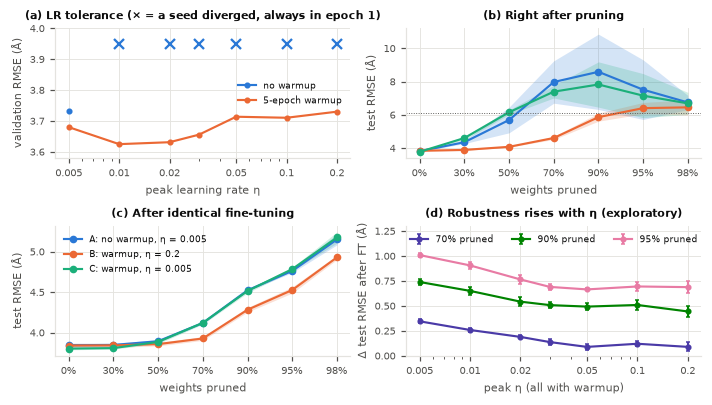

In [48]:
with plt.rc_context(small):
    fig, axes = plt.subplots(2, 2, figsize=(6.7, 3.7))
    ax = axes[0, 0]
    for warmup, colour, name in [(False, BLUE, "no warmup"), (True, ORANGE, "5-epoch warmup")]:
        s = sweep_summary.loc[warmup]
        ok = s["diverged_seeds"] == 0
        ax.plot(s.index[ok], s["val_rmse"][ok], color=colour, marker="o", label=name)
        bad = s.index[s["diverged_seeds"] > 0]
        ax.plot(bad, [3.95] * len(bad), "x", color=colour, markersize=6, markeredgewidth=1.5)
    ax.set(xscale="log", ylim=(3.58, 4.0), xlabel="peak learning rate η", ylabel="validation RMSE (Å)",
           title="(a) LR tolerance (× = a seed diverged, always in epoch 1)")
    decimal_lr_axis(ax, [0.005, 0.01, 0.02, 0.05, 0.1, 0.2])
    ax.legend(loc="center right")

    names = {A: "A: no warmup, η = 0.005", B: "B: warmup, η = 0.2", C: "C: warmup, η = 0.005"}
    for ax, metric, title in [(axes[0, 1], "test_rmse_before_ft", "(b) Right after pruning"),
                              (axes[1, 0], "test_rmse_after_ft", "(c) After identical fine-tuning")]:
        sparsity_plot(pruning, metric, ax, [A, B, C], colours, title)
        ax.set_ylabel("test RMSE (Å)")
    axes[0, 1].axhline(6.136, color=TEXT_SECONDARY, linewidth=0.6, linestyle=":")
    handles, _ = axes[1, 0].get_legend_handles_labels()
    axes[1, 0].legend(handles, [names[n] for n in [A, B, C]], loc="upper left")

    ax = axes[1, 1]
    for colour, s_ in zip([VIOLET, GREEN, MAGENTA], [0.7, 0.9, 0.95]):
        g = dose[dose.sparsity == s_].groupby("lr")["delta"]
        ax.errorbar(g.mean().index, g.mean(), yerr=g.std(), color=colour, marker="o", capsize=1.5, label=f"{s_:.0%} pruned")
    ax.set(xscale="log", ylim=(0, 1.3), xlabel="peak η (all with warmup)", ylabel="Δ test RMSE after FT (Å)",
           title="(d) Robustness rises with η (exploratory)")
    decimal_lr_axis(ax, [0.005, 0.01, 0.02, 0.05, 0.1, 0.2])
    ax.legend(ncol=3, loc="upper center")
    fig.tight_layout()
    save_report(fig, "fig3_warmup_pruning")
    plt.show()